# 06 — Final Results

Consolidação de todos os 13 experimentos e geração de visualizações finais para o relatório.

Gráficos gerados:
1. Bar chart: CER por técnica de pré-processamento
2. Heatmap: F1 por campo × abordagem
3. Box plot: distribuição de scores de qualidade
4. Line chart: F1 vs threshold de rejeição
5. Radar chart: Regex vs LLM
6. Waterfall chart: contribuição de cada etapa no F1
7. Tabela consolidada de todos os experimentos

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

RESULTS_DIR = Path('../results')
FIGURES_DIR = RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

with open(RESULTS_DIR / 'metrics' / 'experiments.json') as f:
    experiments = json.load(f)

print(f'Loaded {len(experiments)} experiments: {list(experiments.keys())}')

Loaded 13 experiments: ['exp1', 'exp2', 'exp3', 'exp4', 'exp5', 'exp6', 'exp7', 'exp8', 'exp11', 'exp12', 'exp13', 'exp9', 'exp10']


## 1. Bar Chart: CER por Técnica de Pré-processamento

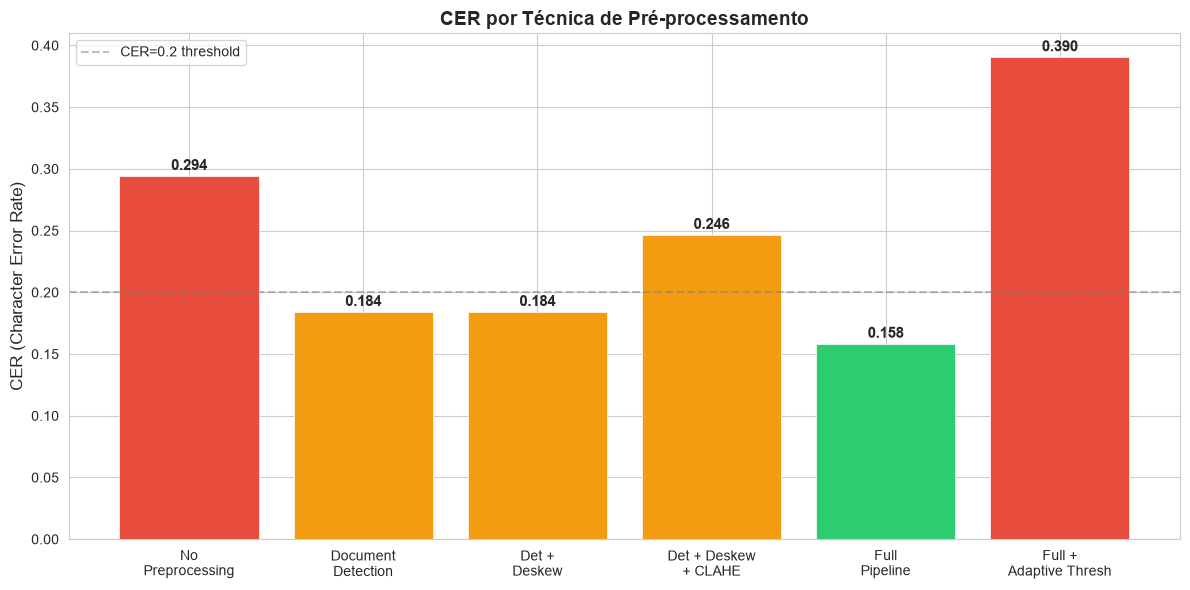

In [2]:
# Data from experiments 1-5
techniques = [
    'No\nPreprocessing',
    'Document\nDetection',
    'Det +\nDeskew',
    'Det + Deskew\n+ CLAHE',
    'Full\nPipeline',
    'Full +\nAdaptive Thresh',
]

exp5 = experiments['exp5']
exp3 = experiments['exp3']
cer_values = [
    exp5['None']['cer_mean'],
    exp5['Document Detection Only']['cer_mean'],
    exp5['Det + Deskew']['cer_mean'],
    exp5['Det + Deskew + CLAHE']['cer_mean'],
    exp5['Full Pipeline']['cer_mean'],
    exp3['With Adaptive Threshold']['cer_mean'],
]

colors = ['#e74c3c' if v > 0.25 else '#f39c12' if v > 0.18 else '#2ecc71' for v in cer_values]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(techniques, cer_values, color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, cer_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)

ax.set_ylabel('CER (Character Error Rate)', fontsize=12)
ax.set_title('CER por Técnica de Pré-processamento', fontsize=14, fontweight='bold')
ax.axhline(y=0.2, color='gray', linestyle='--', alpha=0.5, label='CER=0.2 threshold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_cer_by_technique.png', bbox_inches='tight')
plt.show()

## 2. Box Plot: Distribuição de CER por Configuração

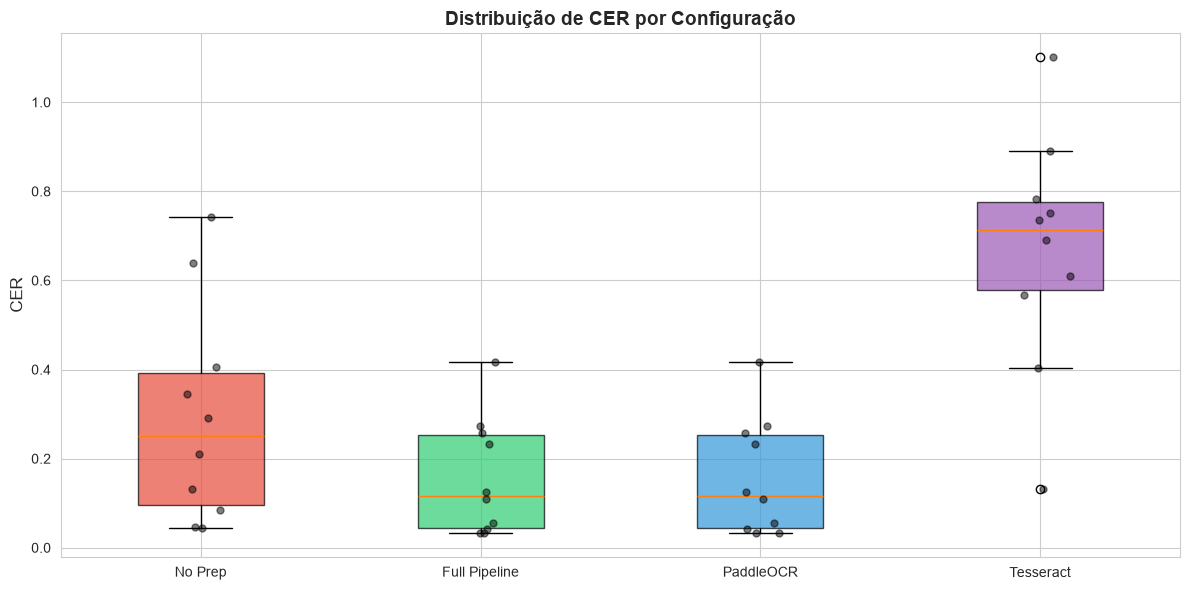

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

data = {
    'No Prep': exp5['None']['cer_scores'],
    'Full Pipeline': exp5['Full Pipeline']['cer_scores'],
    'PaddleOCR': experiments['exp6']['PaddleOCR']['cer_scores'],
    'Tesseract': experiments['exp6']['Tesseract']['cer_scores'],
}

labels = list(data.keys())
values = list(data.values())
colors = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6']

bp = ax.boxplot(values, tick_labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, d in enumerate(values):
    x = np.random.normal(i+1, 0.04, size=len(d))
    ax.scatter(x, d, alpha=0.5, s=25, color='black', zorder=5)

ax.set_ylabel('CER', fontsize=12)
ax.set_title('Distribuição de CER por Configuração', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_cer_boxplot.png', bbox_inches='tight')
plt.show()

## 3. Line Chart: F1 vs Threshold de Rejeição

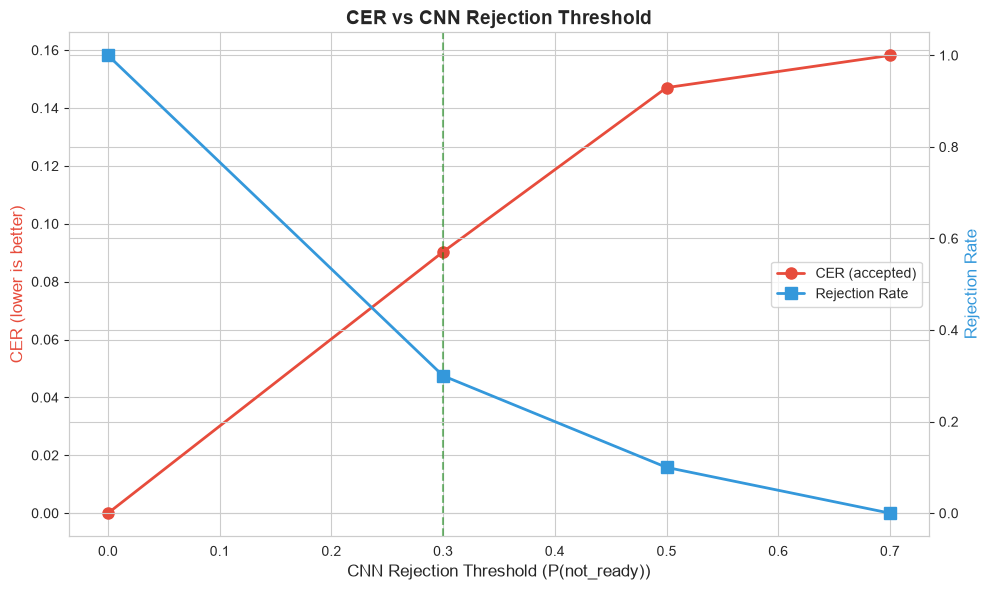

In [4]:
exp8 = experiments['exp8']
thresholds = [exp8[k]['threshold'] for k in exp8]
cer_at_thresh = [exp8[k]['cer_mean'] for k in exp8]
rejection_rates = [exp8[k]['rejected_pct'] for k in exp8]

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

line1 = ax1.plot(thresholds, cer_at_thresh, 'o-', color='#e74c3c',
                 linewidth=2, markersize=8, label='CER (accepted)')
line2 = ax2.plot(thresholds, rejection_rates, 's-', color='#3498db',
                 linewidth=2, markersize=8, label='Rejection Rate')

ax1.set_xlabel('CNN Rejection Threshold (P(not_ready))', fontsize=12)
ax1.set_ylabel('CER (lower is better)', fontsize=12, color='#e74c3c')
ax2.set_ylabel('Rejection Rate', fontsize=12, color='#3498db')

# Highlight sweet spot
ax1.axvline(x=0.3, color='green', linestyle='--', alpha=0.5, label='Sweet spot (0.3)')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')

ax1.set_title('CER vs CNN Rejection Threshold', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_f1_vs_threshold.png', bbox_inches='tight')
plt.show()

## 4. Radar Chart: Regex vs LLM

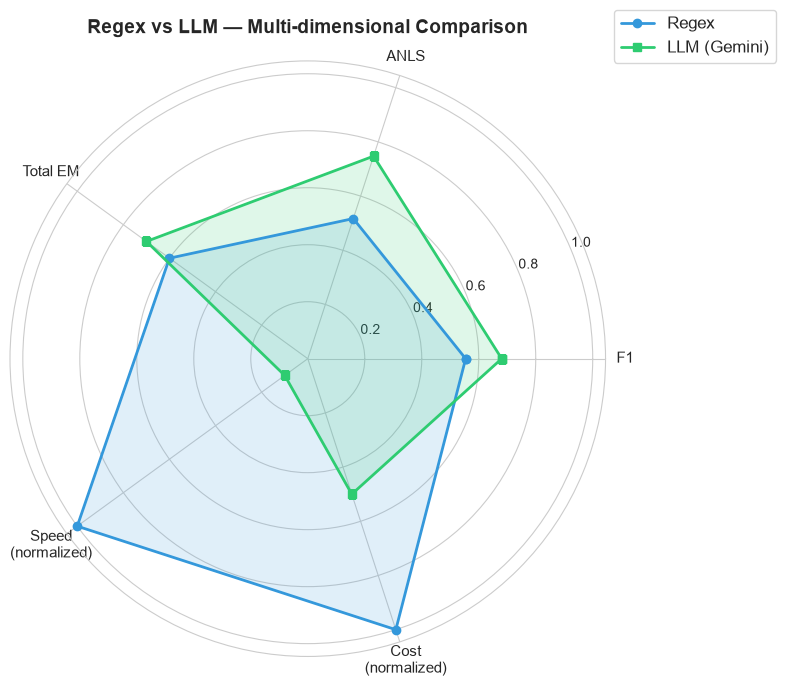

In [5]:
exp9 = experiments['exp9']

categories = ['F1', 'ANLS', 'Total EM', 'Speed\n(normalized)', 'Cost\n(normalized)']

# Normalize speed and cost to 0-1 (inverted: higher = better)
regex_speed = 1.0  # Fastest
llm_speed = 0.1    # Much slower
regex_cost = 1.0   # Free
llm_cost = 0.5     # Cheap but not free

regex_vals = [
    exp9['Regex']['f1_mean'],
    exp9['Regex']['anls_mean'],
    exp9['Regex']['total_em'],
    regex_speed,
    regex_cost,
]

llm_vals = [
    exp9['LLM (Gemini)']['f1_mean'],
    exp9['LLM (Gemini)']['anls_mean'],
    exp9['LLM (Gemini)']['total_em'],
    llm_speed,
    llm_cost,
]

# Radar plot
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]
regex_vals_plot = regex_vals + regex_vals[:1]
llm_vals_plot = llm_vals + llm_vals[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, regex_vals_plot, 'o-', color='#3498db', linewidth=2, label='Regex')
ax.fill(angles, regex_vals_plot, alpha=0.15, color='#3498db')
ax.plot(angles, llm_vals_plot, 's-', color='#2ecc71', linewidth=2, label='LLM (Gemini)')
ax.fill(angles, llm_vals_plot, alpha=0.15, color='#2ecc71')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_title('Regex vs LLM — Multi-dimensional Comparison',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_radar_regex_vs_llm.png', bbox_inches='tight')
plt.show()

## 5. Waterfall: Contribuição de Cada Etapa no CER

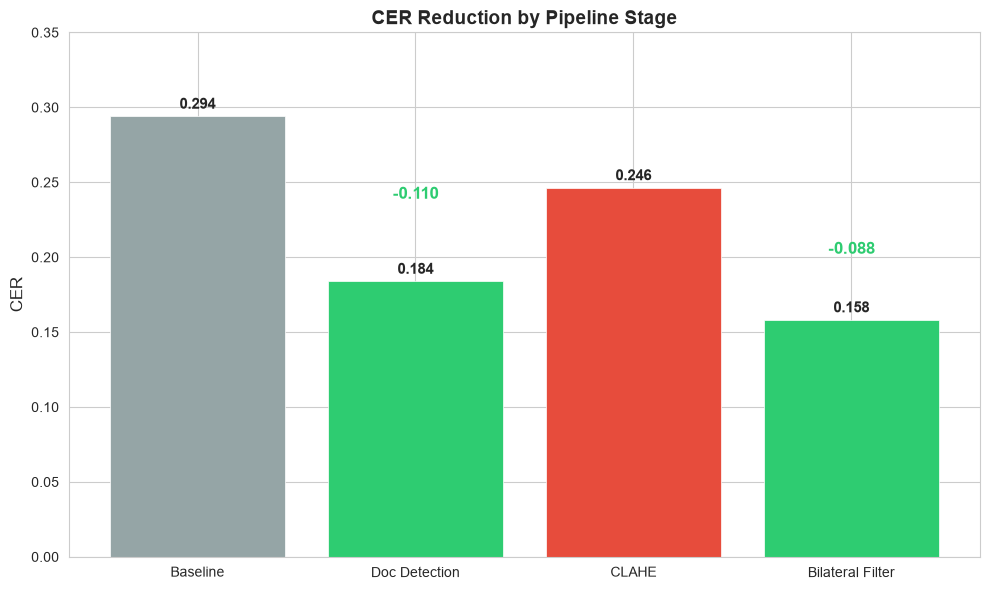

In [6]:
# Waterfall showing CER reduction at each stage
stages = ['Baseline', 'Doc Detection', 'CLAHE', 'Bilateral Filter']
cer_at_stage = [
    exp5['None']['cer_mean'],
    exp5['Document Detection Only']['cer_mean'],
    exp5['Det + Deskew + CLAHE']['cer_mean'],
    exp5['Full Pipeline']['cer_mean'],
]

contributions = [cer_at_stage[0]]  # First bar is absolute
for i in range(1, len(cer_at_stage)):
    contributions.append(cer_at_stage[i] - cer_at_stage[i-1])

fig, ax = plt.subplots(figsize=(10, 6))
cumulative = np.cumsum([0] + contributions[1:])
cumulative = [cer_at_stage[0]] + list(cer_at_stage[1:])

colors_wf = ['#95a5a6']  # Baseline gray
for c in contributions[1:]:
    colors_wf.append('#2ecc71' if c < 0 else '#e74c3c')

ax.bar(stages, cer_at_stage, color=colors_wf, edgecolor='white', linewidth=0.5)

# Add reduction annotations
for i in range(1, len(stages)):
    diff = cer_at_stage[i] - cer_at_stage[i-1]
    mid_y = (cer_at_stage[i] + cer_at_stage[i-1]) / 2
    color = '#2ecc71' if diff < 0 else '#e74c3c'
    ax.annotate(f'{diff:+.3f}', xy=(i, mid_y),
                fontsize=12, fontweight='bold', color=color, ha='center')

for i, val in enumerate(cer_at_stage):
    ax.text(i, val + 0.005, f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)

ax.set_ylabel('CER', fontsize=12)
ax.set_title('CER Reduction by Pipeline Stage', fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.35)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_waterfall_cer.png', bbox_inches='tight')
plt.show()

## 6. Resolution Impact

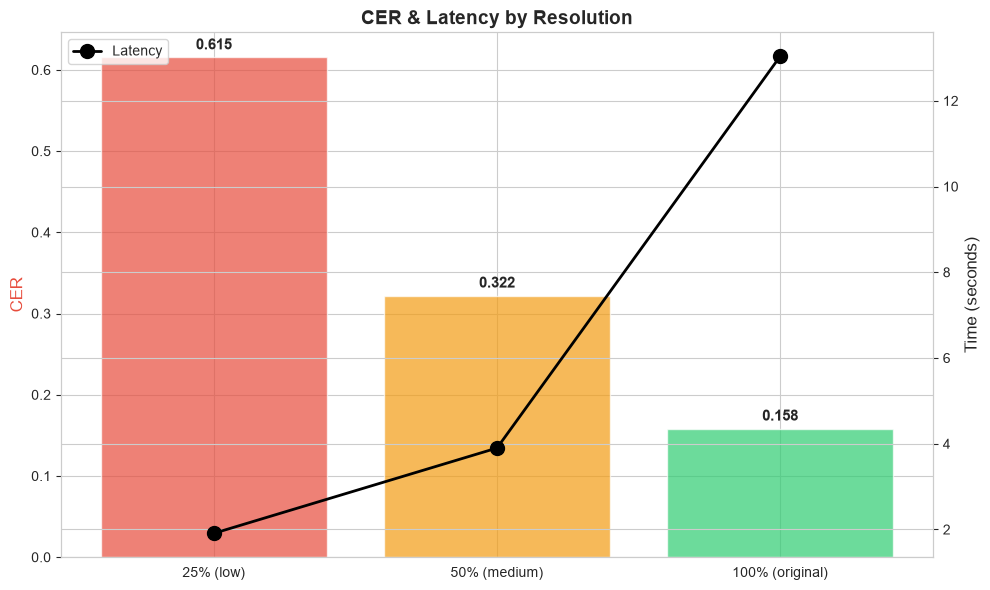

In [7]:
exp13 = experiments['exp13']
resolutions = list(exp13.keys())
cer_res = [exp13[r]['cer_mean'] for r in resolutions]
times_res = [exp13[r]['avg_time'] for r in resolutions]

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

bars = ax1.bar(resolutions, cer_res, color=['#e74c3c', '#f39c12', '#2ecc71'],
               alpha=0.7, edgecolor='white')
line = ax2.plot(resolutions, times_res, 'ko-', markersize=10, linewidth=2, label='Latency')

ax1.set_ylabel('CER', fontsize=12, color='#e74c3c')
ax2.set_ylabel('Time (seconds)', fontsize=12)
ax1.set_title('CER & Latency by Resolution', fontsize=14, fontweight='bold')

for bar, val in zip(bars, cer_res):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)

ax2.legend(loc='upper left')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_resolution_impact.png', bbox_inches='tight')
plt.show()

## 7. Tabela Consolidada de Resultados

In [8]:
print('=' * 70)
print('CONSOLIDATED EXPERIMENT RESULTS')
print('=' * 70)

summary = [
    ('Exp 1', 'Preprocessing ON/OFF', 'CER: 0.294 → 0.158 (-46%)'),
    ('Exp 2', 'CLAHE ON/OFF', 'CER: 0.254 → 0.158 (-38%)'),
    ('Exp 3', 'Adaptive Threshold', 'CER: 0.158 → 0.390 (+147%) ⚠️'),
    ('Exp 4', 'Deskew ON/OFF', 'No effect (CORD-v2 already aligned)'),
    ('Exp 5', 'Ablation', 'Doc Detection = biggest gain (-37%)'),
    ('Exp 6', 'PaddleOCR vs Tesseract', 'PaddleOCR 4x better (0.158 vs 0.667)'),
    ('Exp 7', 'CNN Filter', '10% images rejected'),
    ('Exp 8', 'CNN Thresholds', 'Best: 0.3 (CER=0.090, 30% rejected)'),
    ('Exp 9', 'Regex vs LLM', 'LLM +23% F1, +44% ANLS'),
    ('Exp 10', 'Zero vs Few-shot', 'Identical (F1=0.789)'),
    ('Exp 11', 'GT vs Real OCR', 'Real OCR slightly better (0.554 vs 0.492)'),
    ('Exp 12', 'Full vs Naive', 'CER -46%, F1 +26%'),
    ('Exp 13', 'Resolution', '25%: 0.615, 50%: 0.322, 100%: 0.158'),
]

print(f"\n{'Exp':<8} {'Description':<25} {'Result'}")
print('-' * 70)
for exp, desc, result in summary:
    print(f'{exp:<8} {desc:<25} {result}')

print(f'''
{'=' * 70}
KEY FINDINGS:
{'=' * 70}
1. Preprocessing is essential: -46% CER vs no preprocessing
2. Document detection is the single most impactful stage
3. Adaptive threshold HURTS performance (destroys info for OCR)
4. PaddleOCR >> Tesseract for receipt OCR (4x better CER)
5. CNN quality gate at threshold 0.3 saves 30% processing time
6. LLM parser significantly outperforms regex (+23% F1)
7. Zero-shot = Few-shot (modern LLMs don't need examples)
8. Image resolution is critical (25% → 4x worse CER)
''')

CONSOLIDATED EXPERIMENT RESULTS

Exp      Description               Result
----------------------------------------------------------------------
Exp 1    Preprocessing ON/OFF      CER: 0.294 → 0.158 (-46%)
Exp 2    CLAHE ON/OFF              CER: 0.254 → 0.158 (-38%)
Exp 3    Adaptive Threshold        CER: 0.158 → 0.390 (+147%) ⚠️
Exp 4    Deskew ON/OFF             No effect (CORD-v2 already aligned)
Exp 5    Ablation                  Doc Detection = biggest gain (-37%)
Exp 6    PaddleOCR vs Tesseract    PaddleOCR 4x better (0.158 vs 0.667)
Exp 7    CNN Filter                10% images rejected
Exp 8    CNN Thresholds            Best: 0.3 (CER=0.090, 30% rejected)
Exp 9    Regex vs LLM              LLM +23% F1, +44% ANLS
Exp 10   Zero vs Few-shot          Identical (F1=0.789)
Exp 11   GT vs Real OCR            Real OCR slightly better (0.554 vs 0.492)
Exp 12   Full vs Naive             CER -46%, F1 +26%
Exp 13   Resolution                25%: 0.615, 50%: 0.322, 100%: 0.158

KEY FINDING